# 6 - Simple Inversion

This notebook constructs and solves a baseline Bayesian inversion that maps synthetic satellite altimetry observations to a spatially distributed field of ice-thickness change. It serves as the methodological centerpiece of the project: after establishing the forward model in isolation, we close the loop and recover an estimate of the underlying geophysical signal from noisy data.

The inversion is simple in the sense that it operates within a single Gaussian prior — extensions to the activator-weighted prior are deferred to later notebooks. Nevertheless, it demonstrates all the essential components of the inference pipeline: prior specification, observation operator construction, posterior conditioning, and propagation of uncertainty into the sea-level fingerprint and global mean sea level (GMSL) estimate. 


## Setup

We begin by importing the core scientific Python stack alongside the project-specific packages pygeoinf and pyslfp. pygeoinf provides the abstract infrastructure for Gaussian measures and linear operators on Hilbert spaces, while pyslfp implements the geophysical forward operators that connect ice-thickness change to sea-surface height and sea-level change.

In [ ]:
import colorcet as cc
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

from pygeoinf import (
    CGMatrixSolver,
    GaussianMeasure,
    LinearBayesianInversion,
    LinearForwardProblem,
)
from pyslfp import (
    FingerPrint,
    IceModel,
    averaging_operator,
)

from project import colors
from pygeoinf_extras import standard_dev
from pygeoinf_extras.operators import (
    point_averaging_operator,
)
from pyslfp_extras.ice_thickness import IceSheetChange
from pyslfp_extras.plotting import plot

fig_format = "pdf"
NOTEBOOK_DIR = Path.cwd()
FIGURES_DIR = NOTEBOOK_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Notebook directory: {NOTEBOOK_DIR}")
print(f"Figures will be saved to: {FIGURES_DIR}")

Notebook directory: /Users/th/Documents/pt-3-project/notebooks
Figures will be saved to: /Users/th/Documents/pt-3-project/notebooks/figures/png


## Define Prior and Forward Operator

The inversion requires two ingredients: a prior probability distribution over ice-thickness change, and a forward operator that maps from that field to the altimetry observations.
The prior is specified as a Gaussian measure $\mu_0 = \mathcal{N}(0, C_0)$ on the function space of ice-thickness perturbations. This choice encodes a smoothness assumption on the ice-thickness field that is consistent with the physical length scales of ice dynamics, while remaining computationally tractable through its Sobolev-space representation.

The forward operator $F$ is assembled as an operator chain,

$F: h \;\longmapsto\; q \;\longmapsto\; \eta$

where: 
- $h$ denotes ice-thickness change
- $q$ the corresponding surface load anomaly
- $\eta$ the predicted sea-surface height at the altimetry measurement locations. 

Each link in the chain is supplied by IceSheetChange, which also carries the prior measure, ensuring consistency between the prior covariance and the operators used in the inversion.


Forward operator: 16641 -> 1402


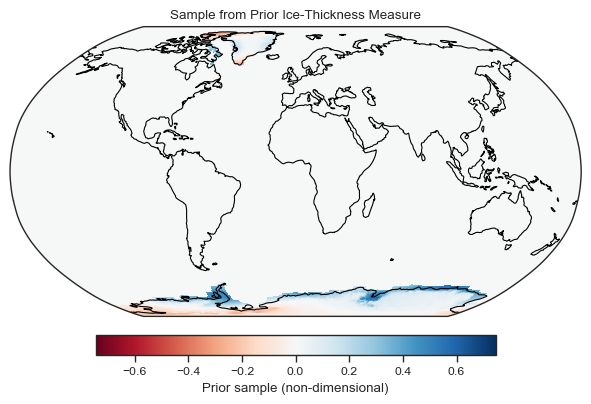

In [2]:
lmax = 128
altimetry_degree_density = 5.0

fp = FingerPrint(lmax=lmax)
fp.set_state_from_ice_ng(version=IceModel.ICE7G, date=0.0)
fp_op = fp.as_sobolev_linear_operator(
    2, fp.mean_sea_floor_radius * 0.1
)

ice_change = IceSheetChange.global_ice(
    finger_print=fp,
    finger_print_operator=fp_op,
    length_scale=0.1 * fp.mean_sea_floor_radius,
    pattern=IceSheetChange.ThicknessWeightedPattern(),
    ice_gmsl_std=0.01,
    point_degree_spacing=altimetry_degree_density,
)

ice_thickness_measure = ice_change.ice_thickness
ice_thickness_to_ssh_point_estimations_op = (
    ice_change.load_to_ssh_point_estimations_operator
    @ ice_change.ice_thickness_to_load_operator
)

model_space = ice_thickness_measure.domain
data_space = (
    ice_thickness_to_ssh_point_estimations_op.codomain
)

print(
    f"Forward operator: {model_space.dim} -> {data_space.dim}"
)

fig, ax, im = plot(
    ice_thickness_measure.sample(),
    symmetric=True,
    colorbar_label="Prior sample (non-dimensional)",
)
ax.set_title("Sample from Prior Ice-Thickness Measure")
plt.show()

## Generate Synthetic Truth and Data

To validate the inversion, we work with a synthetic experiment: a *true* ice-thickness field $h^\dagger$
 is drawn as a single sample from the prior measure $\mu_0$​, providing a plausible but non-trivial test case that is, by construction, consistent with our prior assumptions.

Synthetic altimetry observations are then generated by passing $h^\dagger$ through the forward operator and adding Gaussian noise:

$$d = F h^\dagger + \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, C_\varepsilon)$$

where the noise covariance $C_\varepsilon$
reflects the measurement uncertainty of the altimeter. Because the true field is known, we can assess the quality of the posterior estimate quantitatively at the end of the notebook. 

In [3]:
altimetry_std_dev = 0.001
data_error_measure = (
    GaussianMeasure.from_standard_deviation(
        data_space, altimetry_std_dev
    )
)

forward_problem = LinearForwardProblem(
    ice_thickness_to_ssh_point_estimations_op,
    data_error_measure=data_error_measure,
)

model_true, data = forward_problem.synthetic_model_and_data(
    ice_thickness_measure
)

print(f"Model dimension: {model_true.data.size}")
print(f"Data dimension: {data.shape[0]}")

Model dimension: 67081
Data dimension: 1402


## Run Bayesian Inversion

Given the observations $d$, we seek the posterior measure $\mu_1 = \mathcal{N}(h_1, C_1)$ obtained by conditioning $\mu_0$ on the likelihood. For a linear-Gaussian model this conditioning is exact and yields the well-known update equations,

$$h_1 = C_0 F^*(F C_0 F^* + C_\varepsilon)^{-1} d,$$
$$C_1 = C_0 - C_0 F^*(F C_0 F^* + C_\varepsilon)^{-1} F C_0.$$

In practice, the posterior mean $h_1$ is computed by solving the equivalent regularised normal equations using a conjugate-gradient (CG) solver, avoiding the need to form or invert the full operator $(F C_0 F^* + C_\varepsilon)$ explicitly. Convergence of the CG iterations is monitored to confirm that the solver has reached an acceptable tolerance before the solution is accepted.

In [4]:
bayesian_inversion = LinearBayesianInversion(
    forward_problem, ice_thickness_measure
)

residuals = []
pbar = tqdm(desc="CG solve")


def progress_callback(xk):
    residuals.append(np.linalg.norm(xk))
    pbar.set_postfix({"||x||": f"{residuals[-1]:.2e}"})
    pbar.update(1)


model_posterior_measure = (
    bayesian_inversion.model_posterior_measure(
        data, CGMatrixSolver(callback=progress_callback)
    )
)
pbar.close()

model_posterior_expectation = (
    model_posterior_measure.expectation
)
print("Inversion complete.")

CG solve: 126it [00:48,  2.58it/s, ||x||=3.63e+04]

Inversion complete.


## Compare True and Recovered Ice Thickness

We visualise the synthetic truth $h^\dagger$ and the posterior expectation $h_1$ on a common colour scale. This comparison gives an immediate qualitative sense of how well the inversion has recovered the structure.

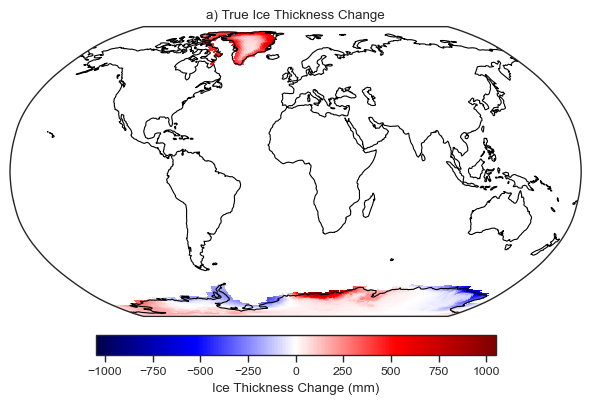

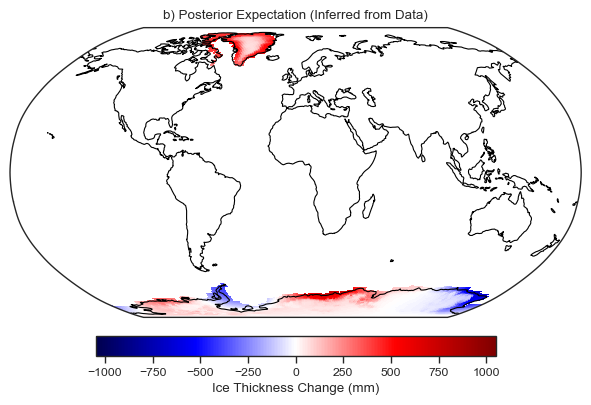

In [5]:
max_abs_ice_change = (
    np.nanmax(
        np.abs(
            np.concatenate(
                [
                    model_true.data.flatten(),
                    model_posterior_expectation.data.flatten(),
                ]
            )
        )
    )
    * 1000
    * fp.length_scale
)

fig1, ax1, im1 = plot(
    1000
    * model_true
    * fp.length_scale
    * fp.ice_projection(),
    coasts=True,
    cmap="seismic",
    vmin=-max_abs_ice_change,
    vmax=max_abs_ice_change,
    colorbar_label="Ice Thickness Change (mm)",
)
ax1.set_title("a) True Ice Thickness Change")
fig1.savefig(
    FIGURES_DIR / f"6-1_true_ice_thickness.{fig_format}",
    dpi=600,
    bbox_inches="tight",
)

fig2, ax2, im2 = plot(
    1000
    * model_posterior_expectation
    * fp.length_scale
    * fp.ice_projection(),
    coasts=True,
    cmap="seismic",
    vmin=-max_abs_ice_change,
    vmax=max_abs_ice_change,
    colorbar_label="Ice Thickness Change (mm)",
)
ax2.set_title(
    "b) Posterior Expectation (Inferred from Data)"
)
fig2.savefig(
    FIGURES_DIR
    / f"6-2_posterior_ice_thickness.{fig_format}",
    dpi=600,
    bbox_inches="tight",
)

## Push Posterior into Sea-Level Space

We can propagate both the true and inferred ice-thickness fields through the load-to-SLC operator to obtain their respective sea-level fingerprints.

This step also propagates uncertainty: the posterior covariance $C_1$ is pushed forward through the SLC operator, yielding a spatially varying uncertainty on the inferred fingerprint. Comparing the fingerprints of the truth and the posterior mean reveals how well the inversion recovers not just the ice field itself, but the downstream quantity of geophysical interest.

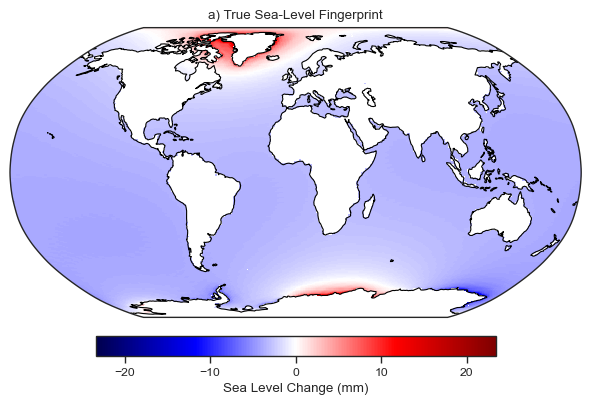

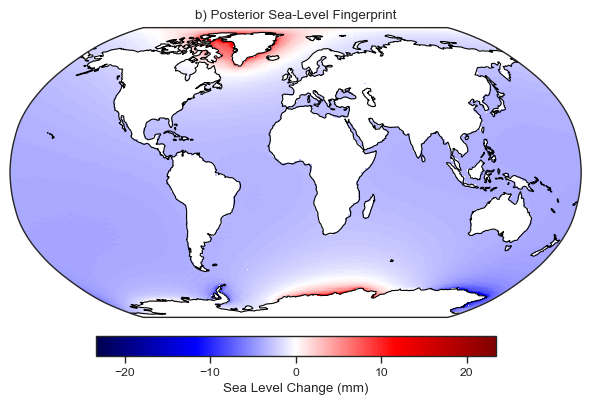

In [6]:
ice_thickness_to_slc_op = (
    ice_change.load_to_slc_operator
    @ ice_change.ice_thickness_to_load_operator
)

sea_level_true = ice_thickness_to_slc_op(model_true)
sea_level_posterior = ice_thickness_to_slc_op(
    model_posterior_expectation
)

if isinstance(sea_level_true, list):
    sea_level_true = sea_level_true[0]
if isinstance(sea_level_posterior, list):
    sea_level_posterior = sea_level_posterior[0]


def as_array(grid):
    if hasattr(grid, "to_array"):
        return grid.to_array()
    if hasattr(grid, "data"):
        return grid.data
    return np.asarray(grid)


max_abs_sl_change = (
    np.nanmax(
        np.abs(
            np.concatenate(
                [
                    as_array(sea_level_true),
                    as_array(sea_level_posterior),
                ]
            )
        )
    )
    * 1000
    * fp.length_scale
)

fig4, ax4, im4 = plot(
    1000
    * sea_level_true
    * fp.length_scale
    * fp.ocean_projection(),
    cmap="seismic",
    vmin=-max_abs_sl_change,
    vmax=max_abs_sl_change,
    colorbar_label="Sea Level Change (mm)",
)
ax4.set_title("a) True Sea-Level Fingerprint")
fig4.savefig(
    FIGURES_DIR / f"6-4_true_sea_level.{fig_format}",
    dpi=600,
    bbox_inches="tight",
)

fig5, ax5, im5 = plot(
    1000
    * sea_level_posterior
    * fp.length_scale
    * fp.ocean_projection(),
    cmap="seismic",
    vmin=-max_abs_sl_change,
    vmax=max_abs_sl_change,
    colorbar_label="Sea Level Change (mm)",
)
ax5.set_title("b) Posterior Sea-Level Fingerprint")
fig5.savefig(
    FIGURES_DIR / f"6-5_posterior_sea_level.{fig_format}",
    dpi=600,
    bbox_inches="tight",
)

plt.show()

## Compare GMSL Estimates

Finally, we collapse the full spatial sea-level fingerprints to a single scalar: the global mean sea level (GMSL) contribution. This is accomplished by applying the GMSL projection operator — a spatially uniform averaging kernel, appropriately area-weighted — to both the posterior distribution and the true field.

For comparison, we also compute an old method GMSL estimate obtained by treating the raw altimetry observations as a direct proxy for sea-level change, without any inversion step. This is the approach criticised in Notebook 01, and its reappearance here allows a direct, quantitative demonstration of the improvement offered by the Bayesian framework.

Consistency between the posterior GMSL estimate and the true value is reported in units of posterior standard deviations ($\sigma$), as is the discrepancy of the old method altimetry estimate.

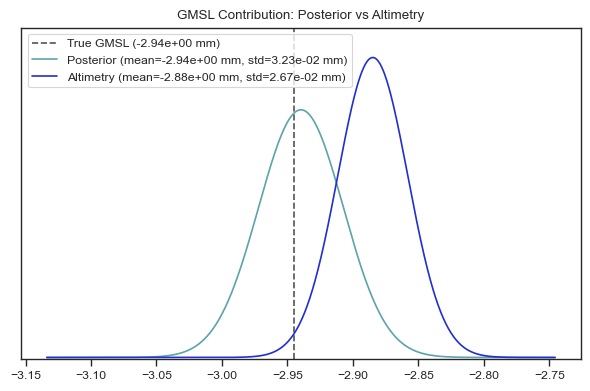

Posterior is -1.55e-01 sigma away from true value.
Altimetry estimation is -2.24e+00 sigma away from true value.


In [7]:
GMSL_weighting_function = (
    -fp.ice_density
    * fp.one_minus_ocean_function
    * fp.ice_projection(value=0)
    * 1000
    * fp.length_scale
    / (fp.water_density * fp.ocean_area)
)
B = averaging_operator(
    model_space, [GMSL_weighting_function]
)

GMSL_true = B(model_true)[0]
GMSL_prior_measure = ice_thickness_measure.affine_mapping(
    operator=B
)
GMSL_posterior_measure = (
    model_posterior_measure.affine_mapping(operator=B)
)

ssh_estimation_alt = (
    ice_change.load_to_point_estimated_gmsl_operator(
        ice_change.ice_thickness_to_load_operator(
            model_true
        )
    )[0]
    * 1000
)

F = point_averaging_operator(data_space)
averaged_error = data_error_measure.affine_mapping(
    operator=F
)
ssh_std = standard_dev(averaged_error) * 1000

prior_expectation = GMSL_prior_measure.expectation[0]
posterior_expectation = GMSL_posterior_measure.expectation[
    0
]
prior_std_dev = standard_dev(GMSL_prior_measure)
posterior_std_dev = standard_dev(GMSL_posterior_measure)

x_prior = np.linspace(
    prior_expectation - 5 * prior_std_dev,
    prior_expectation + 5 * prior_std_dev,
    1000,
)
x_post = np.linspace(
    posterior_expectation - 6 * posterior_std_dev,
    posterior_expectation + 6 * posterior_std_dev,
    1000,
)


def gaussian(x, mean, std_dev):
    return (
        1
        / (std_dev * np.sqrt(2 * np.pi))
        * np.exp(-0.5 * ((x - mean) / std_dev) ** 2)
    )


prior_pdf = gaussian(
    x_prior, prior_expectation, prior_std_dev
)
posterior_pdf = gaussian(
    x_post, posterior_expectation, posterior_std_dev
)
ssh_pdf = gaussian(x_post, ssh_estimation_alt, ssh_std)

y_max = max(
    prior_pdf.max(),
    posterior_pdf.max(),
    ssh_pdf.max(),
)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.axvline(
    GMSL_true,
    color=colors.true,
    linestyle="--",
    label=f"True GMSL ({GMSL_true:.2e} mm)",
)

ax.plot(
    x_post,
    posterior_pdf,
    label=f"Posterior (mean={posterior_expectation:.2e} mm, std={posterior_std_dev:.2e} mm)",
    color=colors.new_method,
)
ax.plot(
    x_post,
    ssh_pdf,
    label=f"Altimetry (mean={ssh_estimation_alt:.2e} mm, std={ssh_std:.2e} mm)",
    color=colors.old_method,
)


ax.get_yaxis().set_visible(False)
ax.set_ylim(-0.1, y_max * 1.1)
ax.set_title("GMSL Contribution: Posterior vs Altimetry")
ax.legend()
plt.tight_layout()
fig.savefig(
    FIGURES_DIR
    / f"6-7_gmsl_distribution_comparison.{fig_format}",
    dpi=600,
    bbox_inches="tight",
)
plt.show()

print(
    f"Posterior is {(GMSL_true - posterior_expectation) / posterior_std_dev:.2e} sigma away from true value."
)
print(
    f"Altimetry estimation is {(GMSL_true - ssh_estimation_alt) / ssh_std:.2e} sigma away from true value."
)